# NB10: 드론 스테이션 후보지 최적화 — Optimization Layer (Step 3)

**목적**: 제약 레이어 통과 셀 중 수요 상위 셀을 선별하고, 인근 공공 유휴공간(주차장/복지센터)과 매칭하여 최종 거점 후보 도출

**알고리즘**: Greedy Set Cover
1. composite_score > 0 인 셀만 추출 (제약 통과)
2. urgency 상위 셀을 수요 핫스팟으로 정의
3. 공공시설 후보지 중 500m 내 핫스팟 커버리지가 높은 순으로 탐욕 선택
4. 전체 핫스팟의 90%+ 커버 시 종료

**입력**:
- `processed/constraint_layers.gpkg` (NB09)
- `processed/public_facilities.gpkg` (NB06)

**출력**: `processed/final_hubs.gpkg` (선정 거점 + 커버리지 정보)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
OUT = BASE / "processed"

# 제약 레이어 (NB09 출력)
gdf = gpd.read_file(OUT / "constraint_layers.gpkg")
print(f"전체 H3 셀: {len(gdf)}")

# 공공시설 후보지 (NB06 출력)
facilities = gpd.read_file(OUT / "public_facilities.gpkg")
print(f"공공시설: {len(facilities)}개소")
print(f"  유형: {facilities['facility'].value_counts().to_dict()}")

전체 H3 셀: 1947
공공시설: 172개소
  유형: {'주차장': 172}


## 1. 후보 셀 필터링

- 제약 통과: `composite_score > 0`
- 수요 핫스팟: `urgency` 상위 30% (또는 0.3 이상)

In [2]:
# 1단계: 제약 통과 셀
feasible = gdf[gdf["composite_score"] > 0].copy()
print(f"제약 통과 셀: {len(feasible)}/{len(gdf)} ({len(feasible)/len(gdf)*100:.1f}%)")

# 2단계: 수요 핫스팟 정의 (urgency 상위 30%)
urgency_threshold = feasible["urgency"].quantile(0.70)
hotspots = feasible[feasible["urgency"] >= urgency_threshold].copy()
print(f"수요 핫스팟 (상위 30%): {len(hotspots)} 셀 (urgency ≥ {urgency_threshold:.3f})")

# 핫스팟 분포
if "GU_NM" in hotspots.columns:
    print(f"\n구별 핫스팟 분포:")
    print(hotspots["GU_NM"].value_counts())

제약 통과 셀: 264/1947 (13.6%)
수요 핫스팟 (상위 30%): 91 셀 (urgency ≥ 0.285)

구별 핫스팟 분포:
GU_NM
분당구    91
Name: count, dtype: int64


## 2. 공공시설 → 핫스팟 매칭 (500m 반경)

각 공공시설 후보지에서 반경 500m 내 핫스팟 셀 수를 카운트

In [3]:
SERVICE_RADIUS = 500  # 드론 스테이션 서비스 반경 (m)

# 시설과 핫스팟을 EPSG:5179 (미터 단위)로 변환
fac_5179 = facilities.to_crs(epsg=5179).copy()

hotspot_centers = gpd.GeoDataFrame(
    hotspots[["h3_index", "urgency", "composite_score"]],
    geometry=gpd.points_from_xy(hotspots["lon"], hotspots["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=5179)

# 각 시설에 500m 버퍼 생성
fac_buf = fac_5179.copy()
fac_buf["geometry"] = fac_buf.buffer(SERVICE_RADIUS)

# Spatial join: 어떤 시설이 어떤 핫스팟을 커버하는지
coverage = gpd.sjoin(hotspot_centers, fac_buf[["geometry"]], predicate="within", how="left")

# 시설별 커버 핫스팟 수 집계
fac_coverage = coverage.groupby("index_right").agg(
    n_hotspots=("h3_index", "count"),
    total_urgency=("urgency", "sum"),
    avg_composite=("composite_score", "mean"),
).reset_index()

# 시설 정보에 매칭
facilities_scored = facilities.copy()
facilities_scored = facilities_scored.merge(
    fac_coverage, left_index=True, right_on="index_right", how="left"
)
facilities_scored["n_hotspots"] = facilities_scored["n_hotspots"].fillna(0).astype(int)
facilities_scored["total_urgency"] = facilities_scored["total_urgency"].fillna(0)

# idle_score가 있으면 종합 점수에 반영
if "idle_score" in facilities_scored.columns:
    facilities_scored["hub_score"] = (
        0.5 * (facilities_scored["n_hotspots"] / max(facilities_scored["n_hotspots"].max(), 1))
        + 0.3 * (facilities_scored["total_urgency"] / max(facilities_scored["total_urgency"].max(), 1))
        + 0.2 * facilities_scored["idle_score"].fillna(0.5)
    )
else:
    facilities_scored["hub_score"] = (
        0.6 * (facilities_scored["n_hotspots"] / max(facilities_scored["n_hotspots"].max(), 1))
        + 0.4 * (facilities_scored["total_urgency"] / max(facilities_scored["total_urgency"].max(), 1))
    )

print(f"\n핫스팟 커버 가능 시설: {(facilities_scored['n_hotspots'] > 0).sum()}개소")
print(f"상위 10 시설:")
top_cols = ["name", "facility", "n_hotspots", "total_urgency", "hub_score"]
top_cols = [c for c in top_cols if c in facilities_scored.columns]
print(facilities_scored.nlargest(10, "hub_score")[top_cols].to_string(index=False))


핫스팟 커버 가능 시설: 4개소
상위 10 시설:
       name facility  n_hotspots  total_urgency  hub_score
       오리환승      주차장          10       4.230382   1.000000
        금곡동      주차장           7       1.997221   0.691634
      구미도서관      주차장           3       1.269115   0.440000
분당도서관 부설주차장      주차장           2       0.570634   0.340467
      수상1-2      주차장           0       0.000000   0.200000
        수상3      주차장           0       0.000000   0.200000
    중상86-87      주차장           0       0.000000   0.200000
    중상22-23      주차장           0       0.000000   0.200000
    중상79상-중      주차장           0       0.000000   0.200000
       중상83      주차장           0       0.000000   0.200000


## 3. Greedy Set Cover — 최소 거점으로 최대 커버리지

1. hub_score 최고 시설 선택
2. 해당 시설 500m 내 핫스팟 제거
3. 남은 핫스팟에 대해 반복
4. 커버리지 90% 달성 또는 최대 20개 시설까지

In [4]:
MAX_HUBS = 20
TARGET_COVERAGE = 0.90

total_hotspots = len(hotspots)
remaining = hotspot_centers.copy()
selected_hubs = []

print(f"Greedy Set Cover 시작: {total_hotspots} 핫스팟, 목표 커버리지 {TARGET_COVERAGE*100}%")
print(f"{'Step':>4}  {'시설명':<25}  {'유형':<10}  {'신규커버':>6}  {'누적커버':>6}  {'커버율':>6}")
print("-" * 85)

for step in range(MAX_HUBS):
    if len(remaining) == 0:
        break
    
    # 각 시설의 남은 핫스팟 커버 수 재계산
    best_fac_idx = -1
    best_covered = set()
    best_score = -1
    
    for fac_idx, fac_row in fac_5179.iterrows():
        if fac_idx in [h["fac_idx"] for h in selected_hubs]:
            continue  # 이미 선택된 시설 제외
        
        fac_point = fac_row.geometry
        # 남은 핫스팟 중 500m 이내
        dists = remaining.geometry.distance(fac_point)
        covered_idx = set(remaining.index[dists <= SERVICE_RADIUS])
        
        # 커버 수 + urgency 가중
        if len(covered_idx) > 0:
            urgency_sum = remaining.loc[list(covered_idx), "urgency"].sum()
            score = len(covered_idx) + 0.1 * urgency_sum
        else:
            score = 0
        
        if score > best_score:
            best_score = score
            best_fac_idx = fac_idx
            best_covered = covered_idx
    
    if best_fac_idx < 0 or len(best_covered) == 0:
        break
    
    # 선택
    fac_info = facilities.loc[best_fac_idx]
    covered_so_far = total_hotspots - len(remaining) + len(best_covered)
    coverage_pct = covered_so_far / total_hotspots
    
    selected_hubs.append({
        "fac_idx": best_fac_idx,
        "name": fac_info.get("name", f"시설_{best_fac_idx}"),
        "facility": fac_info.get("facility", "unknown"),
        "new_covered": len(best_covered),
        "total_covered": covered_so_far,
        "coverage_pct": coverage_pct,
        "geometry": fac_info.geometry,
    })
    
    fname = str(fac_info.get("name", ""))[:25]
    ftype = str(fac_info.get("facility", ""))[:10]
    print(f"{step+1:4d}  {fname:<25}  {ftype:<10}  {len(best_covered):>6d}  {covered_so_far:>6d}  {coverage_pct:>5.1%}")
    
    # 커버된 핫스팟 제거
    remaining = remaining.drop(index=list(best_covered))
    
    if coverage_pct >= TARGET_COVERAGE:
        print(f"\n목표 커버리지 {TARGET_COVERAGE*100}% 달성!")
        break

print(f"\n선정 거점: {len(selected_hubs)}개소")
print(f"최종 커버리지: {selected_hubs[-1]['coverage_pct']:.1%}")

Greedy Set Cover 시작: 91 핫스팟, 목표 커버리지 90.0%
Step  시설명                        유형            신규커버    누적커버     커버율
-------------------------------------------------------------------------------------
   1  오리환승                       주차장             10      10  11.0%
   2  금곡동                        주차장              7      17  18.7%
   3  분당도서관 부설주차장                주차장              2      19  20.9%
   4  구미도서관                      주차장              1      20  22.0%

선정 거점: 4개소
최종 커버리지: 22.0%


## 4. 결과 정리 및 서비스 권역 생성

In [5]:
# 선정 거점 GeoDataFrame
hub_df = pd.DataFrame(selected_hubs)
gdf_hubs = gpd.GeoDataFrame(hub_df, geometry="geometry", crs="EPSG:4326")

# 서비스 권역 (500m 버퍼) 생성
gdf_hubs_5179 = gdf_hubs.to_crs(epsg=5179)
gdf_hubs["service_area"] = gdf_hubs_5179.buffer(SERVICE_RADIUS).to_crs(epsg=4326)

# 각 거점에 추가 정보 매칭
for i, row in gdf_hubs.iterrows():
    fac = facilities.loc[row["fac_idx"]]
    gdf_hubs.loc[i, "address"] = fac.get("address", "")
    gdf_hubs.loc[i, "capacity"] = fac.get("capacity", np.nan)
    gdf_hubs.loc[i, "idle_score"] = fac.get("idle_score", np.nan)
    gdf_hubs.loc[i, "lat"] = fac.geometry.y
    gdf_hubs.loc[i, "lon"] = fac.geometry.x

# terrain_zone: 각 거점이 Green/Yellow 중 어디에 있는지
hub_centers_5179 = gpd.GeoDataFrame(
    gdf_hubs[["name"]],
    geometry=gpd.points_from_xy(gdf_hubs["lon"], gdf_hubs["lat"]),
    crs="EPSG:4326",
)
hub_terrain = gpd.sjoin_nearest(
    hub_centers_5179.to_crs(epsg=5179),
    gdf[["h3_index", "terrain_zone", "avg_slope", "geometry"]].to_crs(epsg=5179),
    how="left",
)
gdf_hubs["terrain_zone"] = hub_terrain["terrain_zone"].values
gdf_hubs["avg_slope"] = hub_terrain["avg_slope"].values

# 배송 모드 결정
gdf_hubs["delivery_mode"] = np.where(
    gdf_hubs["terrain_zone"] == "Green",
    "드론+로봇 Full 배송",
    np.where(
        gdf_hubs["terrain_zone"] == "Yellow",
        "드론 스테이션 → 인간 수령",
        "드론 직배송만 가능"
    )
)

print("=== 최종 거점 목록 ===")
display_cols = ["name", "facility", "terrain_zone", "delivery_mode", 
                "new_covered", "coverage_pct"]
display_cols = [c for c in display_cols if c in gdf_hubs.columns]
print(gdf_hubs[display_cols].to_string(index=False))

=== 최종 거점 목록 ===
       name facility terrain_zone delivery_mode  new_covered  coverage_pct
       오리환승      주차장      Unknown    드론 직배송만 가능           10      0.109890
        금곡동      주차장      Unknown    드론 직배송만 가능            7      0.186813
분당도서관 부설주차장      주차장      Unknown    드론 직배송만 가능            2      0.208791
      구미도서관      주차장      Unknown    드론 직배송만 가능            1      0.219780


## 5. 시각화: 거점 위치 + 서비스 권역 + 핫스팟

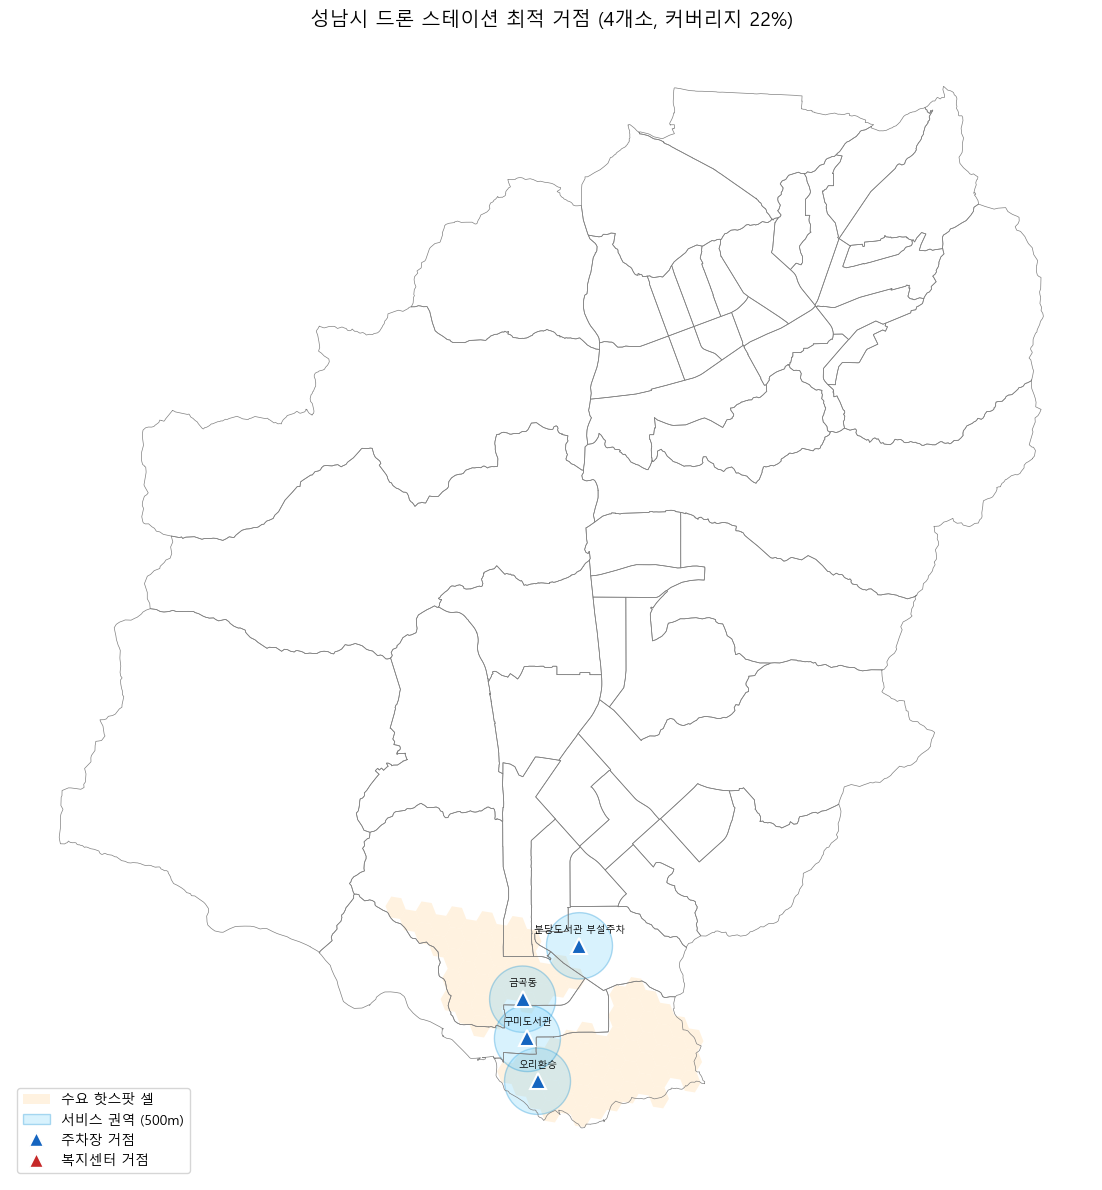

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

seongnam = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong")

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 행정동 경계
seongnam.boundary.plot(ax=ax, color="gray", linewidth=0.5)

# 핫스팟 셀 (배경)
hotspots.plot(ax=ax, color="#FFE0B2", alpha=0.4, edgecolor="none")

# 서비스 권역 (500m 버퍼)
service_areas = gpd.GeoDataFrame(
    gdf_hubs[["name"]], geometry=gdf_hubs["service_area"], crs="EPSG:4326"
)
service_areas.plot(ax=ax, color="#81D4FA", alpha=0.3, edgecolor="#0288D1", linewidth=1)

# 거점 위치
colors = {"주차장": "#1565C0", "행정복지센터": "#C62828"}
for _, hub in gdf_hubs.iterrows():
    color = colors.get(hub["facility"], "#333333")
    ax.plot(hub["lon"], hub["lat"], "^", color=color, markersize=12, 
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)
    ax.annotate(hub["name"][:10], (hub["lon"], hub["lat"]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 8), textcoords="offset points")

# 범례
legend_elements = [
    Patch(facecolor="#FFE0B2", alpha=0.4, label="수요 핫스팟 셀"),
    Patch(facecolor="#81D4FA", alpha=0.3, edgecolor="#0288D1", label=f"서비스 권역 ({SERVICE_RADIUS}m)"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#1565C0",
               markersize=10, label="주차장 거점"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#C62828",
               markersize=10, label="복지센터 거점"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=10)

ax.set_title(f"성남시 드론 스테이션 최적 거점 ({len(selected_hubs)}개소, "
             f"커버리지 {selected_hubs[-1]['coverage_pct']:.0%})", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. 커버리지 분석

=== 구별 핫스팟 커버리지 ===
GU_NM  total_hotspots  covered  coverage_pct
  분당구              93       22          23.7


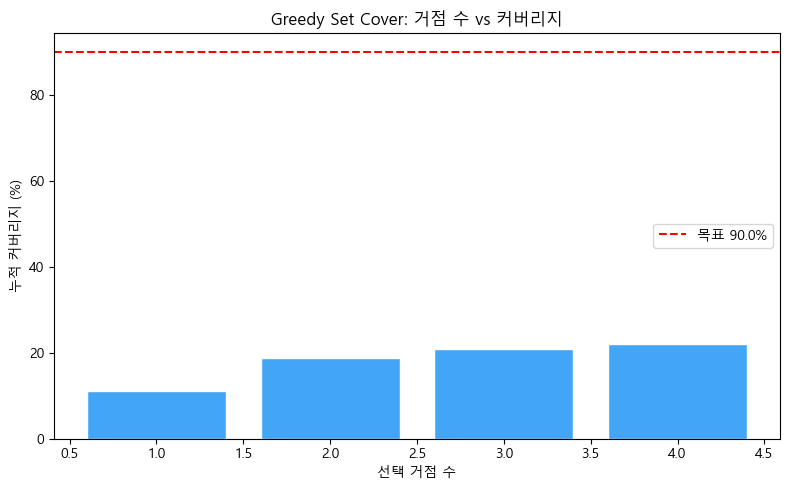

In [7]:
# 구별 커버리지
if "GU_NM" in hotspots.columns:
    # 각 핫스팟이 어떤 거점의 서비스 권역에 포함되는지
    hotspot_pts = gpd.GeoDataFrame(
        hotspots[["h3_index", "GU_NM", "urgency"]],
        geometry=gpd.points_from_xy(hotspots["lon"], hotspots["lat"]),
        crs="EPSG:4326",
    )
    covered_check = gpd.sjoin(hotspot_pts, service_areas, predicate="within", how="left")
    covered_check["is_covered"] = covered_check["index_right"].notna()
    
    # 구별 집계
    gu_stats = covered_check.groupby("GU_NM").agg(
        total_hotspots=("h3_index", "count"),
        covered=("is_covered", "sum"),
    ).reset_index()
    gu_stats["coverage_pct"] = (gu_stats["covered"] / gu_stats["total_hotspots"] * 100).round(1)
    print("=== 구별 핫스팟 커버리지 ===")
    print(gu_stats.to_string(index=False))

# 커버리지 곡선
fig, ax = plt.subplots(figsize=(8, 5))
steps = range(1, len(selected_hubs) + 1)
coverages = [h["coverage_pct"] * 100 for h in selected_hubs]
ax.bar(steps, coverages, color="#42A5F5", edgecolor="white")
ax.axhline(y=TARGET_COVERAGE * 100, color="red", linestyle="--", label=f"목표 {TARGET_COVERAGE*100}%")
ax.set_xlabel("선택 거점 수")
ax.set_ylabel("누적 커버리지 (%)")
ax.set_title("Greedy Set Cover: 거점 수 vs 커버리지")
ax.legend()
plt.tight_layout()
plt.show()

## 7. 저장

In [8]:
# 거점 저장 (포인트 + 메타데이터)
save_cols = ["name", "facility", "address", "lat", "lon",
             "capacity", "idle_score", "terrain_zone", "avg_slope",
             "delivery_mode", "new_covered", "total_covered", 
             "coverage_pct", "geometry"]
save_cols = [c for c in save_cols if c in gdf_hubs.columns]

gdf_hubs_save = gdf_hubs[save_cols].copy()
gdf_hubs_save.to_file(OUT / "final_hubs.gpkg", layer="hubs", driver="GPKG")

# 서비스 권역 폴리곤 저장
service_save = gpd.GeoDataFrame(
    gdf_hubs[["name", "facility", "delivery_mode"]],
    geometry=gdf_hubs["service_area"],
    crs="EPSG:4326",
)
service_save.to_file(OUT / "final_hubs.gpkg", layer="service_areas", driver="GPKG")

# Tableau용 CSV
csv_hubs = gdf_hubs_save.drop(columns="geometry").copy()
csv_hubs.to_csv(OUT / "final_hubs.csv", index=False, encoding="utf-8-sig")

print(f"저장 완료:")
print(f"  {OUT / 'final_hubs.gpkg'} (hubs: {len(gdf_hubs_save)}, service_areas: {len(service_save)})")
print(f"  {OUT / 'final_hubs.csv'}")

저장 완료:
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\final_hubs.gpkg (hubs: 4, service_areas: 4)
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\final_hubs.csv
